Mounted at /content/drive
✓ All libraries imported successfully


╔==============================================================================╗
║                                                                              ║
║            AIR QUALITY NO₂ DOWNSCALING - MULTIPLE LINEAR REGRESSION          ║
║                        39 Weather Stations | Daily Data                      ║
║                         TEMPORAL + SPATIAL VALIDATION                        ║
║                                                                              ║
╚==============================================================================╝

Start time: 2026-02-14 08:40:45

STEP 1: LOADING DATA
✓ Data loaded successfully
  - Rows: 14,274
  - Columns: 15
  - Stations: 39
✓ Date converted to datetime
  - Date range: 2024-01-01 00:00:00 to 2024-12-31 00:00:00
  - Total days: 365

✓ Sample of your data:
       station       lat        lon       date  groundtruth_no2  tropospheric_no2  population_density  

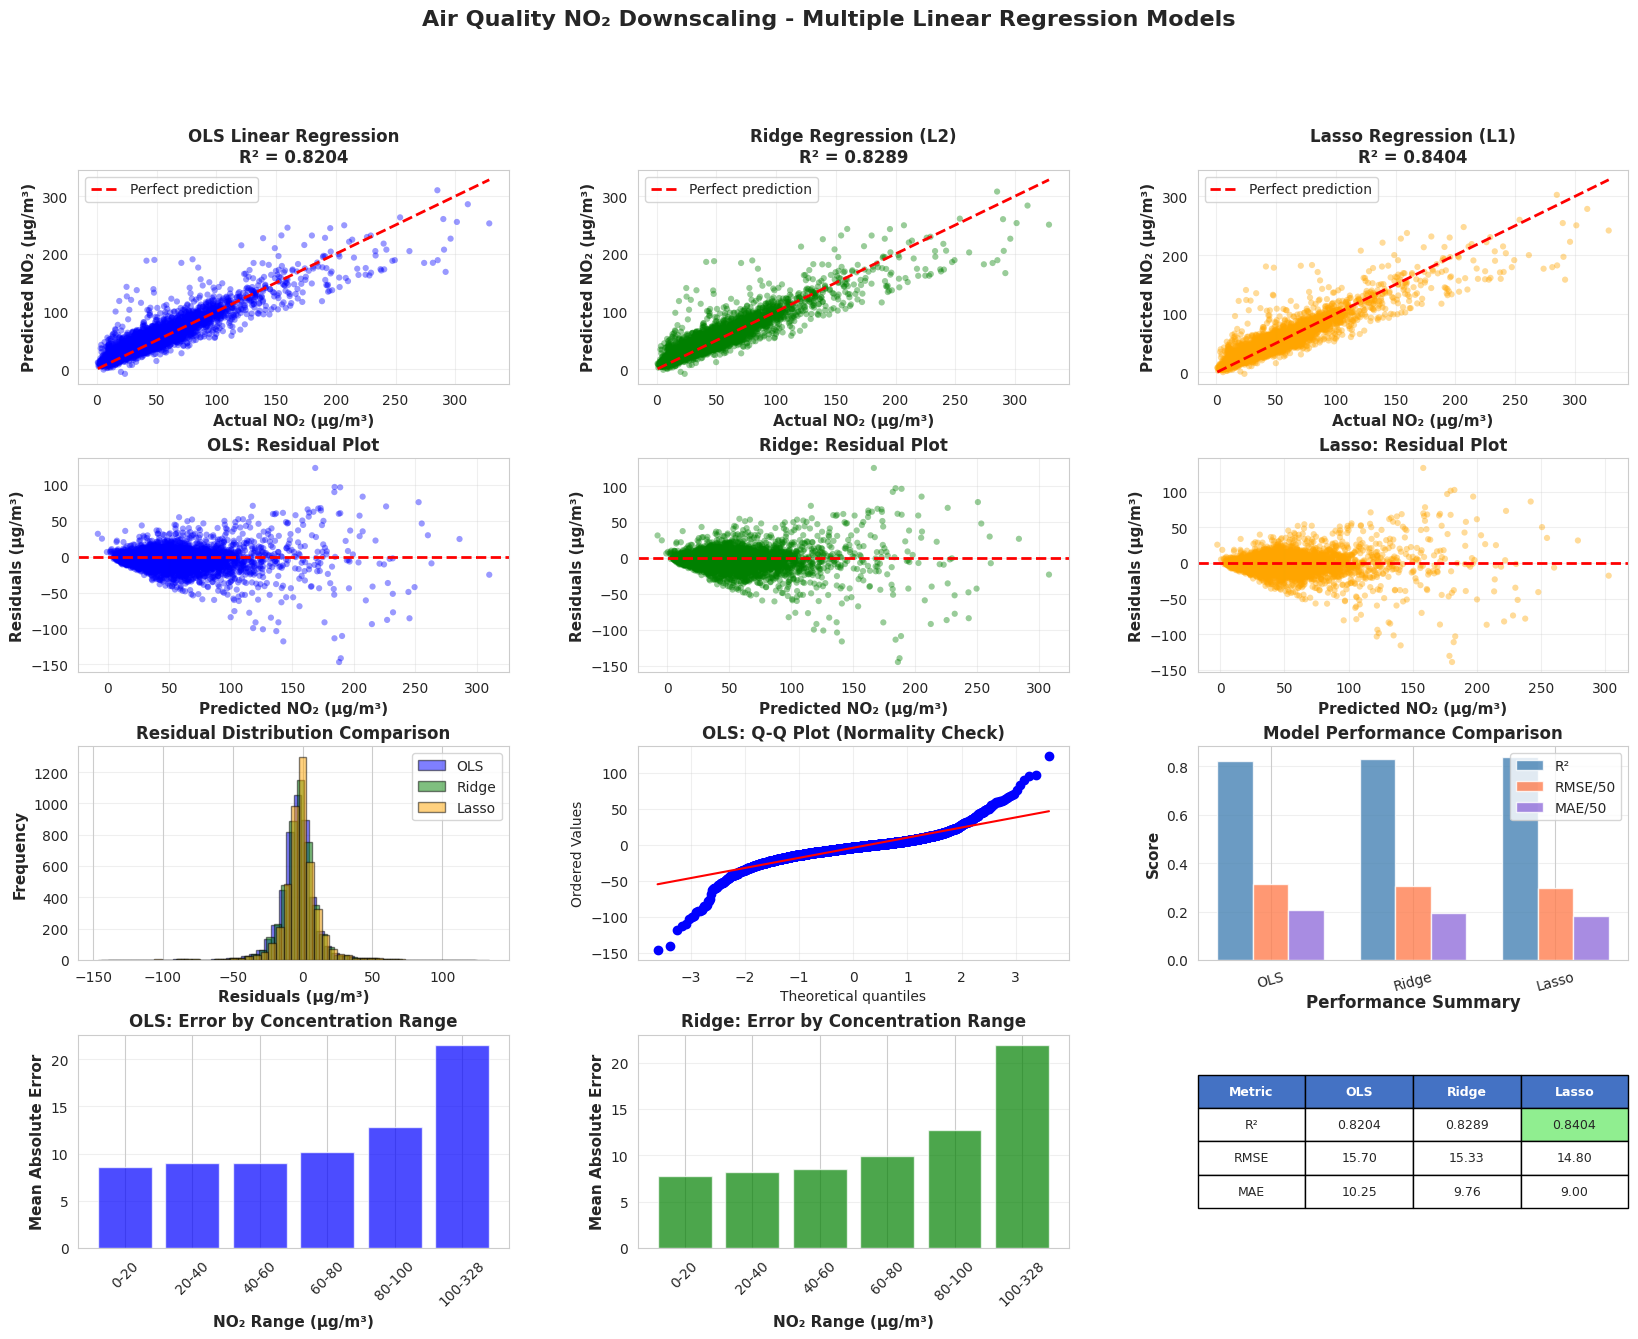


Generating coefficient plots...
✓ Saved: coefficient_importance.png


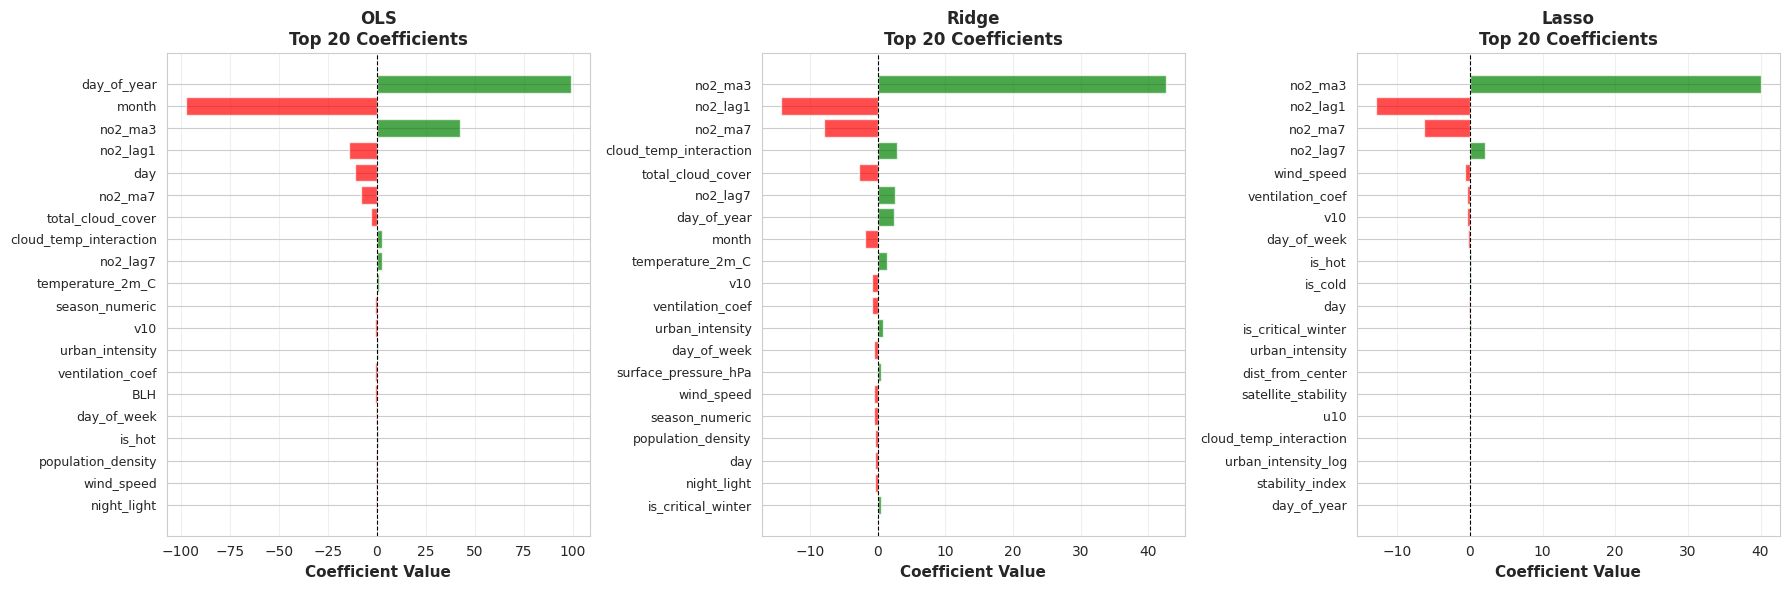


STEP 7: SAVING MODELS TO GOOGLE DRIVE
✓ Saved: /content/drive/MyDrive/MAJOR_PROJECT/trained_models/ols_no2_model.pkl
✓ Saved: /content/drive/MyDrive/MAJOR_PROJECT/trained_models/ridge_no2_model.pkl
✓ Saved: /content/drive/MyDrive/MAJOR_PROJECT/trained_models/lasso_no2_model.pkl
✓ Saved: /content/drive/MyDrive/MAJOR_PROJECT/trained_models/test_station_info.pkl
✓ Saved: /content/drive/MyDrive/MAJOR_PROJECT/trained_models/lasso_selected_features.pkl
✓ Saved: /content/drive/MyDrive/MAJOR_PROJECT/trained_models/model_info.json

✓ All models saved to Google Drive!

Location: /content/drive/MyDrive/MAJOR_PROJECT/trained_models

PIPELINE COMPLETED SUCCESSFULLY! 🎉
End time: 2026-02-14 08:40:56

MODEL COMPARISON SUMMARY
OLS Linear Regression:
  - R²: 0.8204
  - Adjusted R²: 0.8190
  - RMSE: 15.7036 µg/m³

Ridge Regression (L2):
  - R²: 0.8289
  - Adjusted R²: 0.8276
  - RMSE: 15.3272 µg/m³

Lasso Regression (L1):
  - R²: 0.8404
  - Adjusted R²: 0.8392
  - RMSE: 14.8016 µg/m³
  - Features select

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats

print("✓ All libraries imported successfully")

# ============================================================================
# 1. DATA LOADING AND PREPROCESSING
# ============================================================================

def load_and_preprocess_data(filepath):
    """
    Load and preprocess the master dataset
    """
    print("\n" + "=" * 80)
    print("STEP 1: LOADING DATA")
    print("=" * 80)

    # Load data
    df = pd.read_csv(filepath)
    print(f"✓ Data loaded successfully")
    print(f"  - Rows: {df.shape[0]:,}")
    print(f"  - Columns: {df.shape[1]}")
    print(f"  - Stations: {df['station'].nunique()}")

    # Convert date to datetime
    df['date'] = pd.to_datetime(df['date'])
    print(f"✓ Date converted to datetime")
    print(f"  - Date range: {df['date'].min()} to {df['date'].max()}")
    print(f"  - Total days: {(df['date'].max() - df['date'].min()).days}")

    # Display first few rows
    print("\n✓ Sample of your data:")
    print(df.head(3).to_string())

    # Data quality check
    print("\n" + "-" * 80)
    print("DATA QUALITY CHECK")
    print("-" * 80)
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print("Missing values found:")
        for col in missing[missing > 0].index:
            pct = (missing[col] / len(df)) * 100
            print(f"  - {col}: {missing[col]:,} ({pct:.1f}%)")
    else:
        print("✓ No missing values found!")

    return df

def handle_missing_values(df):
    """
    Handle missing values in the dataset
    Strategy: Use spatial-temporal averaging for satellite data gaps (clouds)
    """
    print("\n" + "=" * 80)
    print("STEP 2: HANDLING MISSING VALUES")
    print("=" * 80)

    initial_rows = len(df)

    # 1. Remove rows where target (groundtruth_no2) is missing
    df = df.dropna(subset=['groundtruth_no2'])
    removed = initial_rows - len(df)
    if removed > 0:
        print(f"✓ Removed {removed:,} rows with missing groundtruth_no2")
        print(f"  - Remaining rows: {len(df):,}")
    else:
        print("✓ No missing values in groundtruth_no2")

    # 2. Handle missing tropospheric_no2 (satellite data - gaps due to clouds)
    if df['tropospheric_no2'].isnull().sum() > 0:
        missing_count = df['tropospheric_no2'].isnull().sum()
        print(f"\n✓ Handling {missing_count:,} missing satellite values (cloudy days)")

        # Create indicator for missing satellite data
        df['satellite_missing_flag'] = df['tropospheric_no2'].isnull().astype(int)

        # Fill with station-month average (same location, same season)
        df['tropospheric_no2'] = df.groupby(['station', df['date'].dt.month])['tropospheric_no2'].transform(
            lambda x: x.fillna(x.mean())
        )

        # If still missing, use station average
        df['tropospheric_no2'] = df.groupby('station')['tropospheric_no2'].transform(
            lambda x: x.fillna(x.mean())
        )

        # If STILL missing (entire station has no data), use overall mean
        df['tropospheric_no2'].fillna(df['tropospheric_no2'].mean(), inplace=True)

        print(f"  - Filled using spatial-temporal averaging")
        print(f"  - Added 'satellite_missing_flag' feature")
    else:
        print("✓ No missing satellite data")
        df['satellite_missing_flag'] = 0

    # 3. Check for any remaining missing values in predictors
    predictor_cols = [col for col in df.columns if col not in ['station', 'date', 'groundtruth_no2']]
    remaining_missing = df[predictor_cols].isnull().sum().sum()

    if remaining_missing > 0:
        print(f"\n⚠ Warning: {remaining_missing} missing values in other features")
        print("  - Filling with column means...")
        df[predictor_cols] = df[predictor_cols].fillna(df[predictor_cols].mean())
        print("  ✓ All missing values handled")

    print(f"\n✓ Final dataset: {len(df):,} rows ready for modeling")

    return df

# ============================================================================
# 2. FEATURE ENGINEERING
# ============================================================================

def create_features(df):
    """
    Create additional features to boost model performance
    """
    print("\n" + "=" * 80)
    print("STEP 3: FEATURE ENGINEERING")
    print("=" * 80)

    initial_features = len(df.columns)

    # TEMPORAL FEATURES
    print("\n1. Creating temporal features...")
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['day_of_year'] = df['date'].dt.dayofyear
    df['day_of_week'] = df['date'].dt.dayofweek  # Monday=0, Sunday=6
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    # Season (important for Delhi's air quality)
    df['season'] = df['month'].apply(lambda x:
        'winter' if x in [12, 1, 2] else
        'spring' if x in [3, 4, 5] else
        'summer' if x in [6, 7, 8] else
        'autumn')

    # Convert season to numeric
    season_map = {'winter': 1, 'spring': 2, 'summer': 3, 'autumn': 4}
    df['season_numeric'] = df['season'].map(season_map)

    # Critical winter months (Nov-Feb) when Delhi has worst air quality
    df['is_critical_winter'] = df['month'].apply(lambda x: 1 if x in [11, 12, 1, 2] else 0)

    print(f"   ✓ Added 8 temporal features")

    # METEOROLOGICAL FEATURES
    print("\n2. Creating meteorological features...")

    # Wind direction (important for pollution transport)
    df['wind_direction'] = np.arctan2(df['v10'], df['u10']) * 180 / np.pi
    df['wind_direction'] = (df['wind_direction'] + 360) % 360  # Convert to 0-360

    # Atmospheric stability (higher = more stable = more pollution accumulation)
    df['stability_index'] = df['BLH'] / (df['wind_speed'] + 0.1)

    # Ventilation coefficient (BLH * wind_speed) - higher = better dispersion
    df['ventilation_coef'] = df['BLH'] * df['wind_speed']

    # Temperature categories (impacts chemical reactions)
    df['temp_category'] = pd.cut(df['temperature_2m_C'],
                                   bins=[-np.inf, 15, 25, np.inf],
                                   labels=['cold', 'moderate', 'hot'])
    df['is_cold'] = (df['temperature_2m_C'] < 15).astype(int)
    df['is_hot'] = (df['temperature_2m_C'] > 30).astype(int)

    print(f"   ✓ Added 7 meteorological features")

    # EMISSION PROXY FEATURES
    print("\n3. Creating emission proxy features...")

    # Population-nightlight interaction (urbanization intensity)
    df['urban_intensity'] = df['population_density'] * df['night_light']

    # Normalize for better scaling
    df['urban_intensity_log'] = np.log1p(df['urban_intensity'])

    print(f"   ✓ Added 2 emission proxy features")

    # SPATIAL FEATURES
    print("\n4. Creating spatial features...")

    # Distance from city center (approximate Delhi center: 28.6139°N, 77.2090°E)
    delhi_center_lat, delhi_center_lon = 28.6139, 77.2090
    df['dist_from_center'] = np.sqrt(
        (df['lat'] - delhi_center_lat)**2 +
        (df['lon'] - delhi_center_lon)**2
    ) * 111  # Convert to km (approximate)

    print(f"   ✓ Added 1 spatial feature")

    # TEMPORAL LAG FEATURES (previous days' pollution)
    print("\n5. Creating lag features...")
    df = df.sort_values(['station', 'date'])

    # Yesterday's NO2 (very predictive)
    df['no2_lag1'] = df.groupby('station')['groundtruth_no2'].shift(1)

    # Last week's NO2
    df['no2_lag7'] = df.groupby('station')['groundtruth_no2'].shift(7)

    # 3-day moving average
    df['no2_ma3'] = df.groupby('station')['groundtruth_no2'].transform(
        lambda x: x.rolling(window=3, min_periods=1).mean()
    )

    # 7-day moving average
    df['no2_ma7'] = df.groupby('station')['groundtruth_no2'].transform(
        lambda x: x.rolling(window=7, min_periods=1).mean()
    )

    print(f"   ✓ Added 4 lag features")

    # INTERACTION FEATURES
    print("\n6. Creating interaction features...")

    # Satellite * stability (trapped pollution)
    df['satellite_stability'] = df['tropospheric_no2'] * df['stability_index']

    # Cloudy + cold = worse air quality
    df['cloud_temp_interaction'] = df['total_cloud_cover'] * (1 / (df['temperature_2m_C'] + 1))

    print(f"   ✓ Added 2 interaction features")

    # SUMMARY
    final_features = len(df.columns)
    new_features = final_features - initial_features

    print("\n" + "-" * 80)
    print(f"✓ FEATURE ENGINEERING COMPLETE")
    print(f"  - Started with: {initial_features} columns")
    print(f"  - Created: {new_features} new features")
    print(f"  - Total features: {final_features} columns")
    print("-" * 80)

    return df

# ============================================================================
# 3. DATA PREPARATION
# ============================================================================

def prepare_train_test_split(df, random_state=42):
    """
    Prepare train-test split with TEMPORAL and SPATIAL validation

    TEMPORAL SPLIT:
    - Train: Months 3-11 (March to November)
    - Test: Months 12, 1, 2 (December, January, February - winter months)

    SPATIAL SPLIT:
    - Randomly select 5 stations for testing only (spatial generalization)
    - These stations never seen during training
    """
    print("\n" + "=" * 80)
    print("STEP 4: PREPARING TRAIN-TEST SPLIT")
    print("=" * 80)
    print("\n⚠️  ADVANCED VALIDATION STRATEGY:")
    print("   1. TEMPORAL SPLIT: Train on Mar-Nov, Test on Dec-Feb (winter)")
    print("   2. SPATIAL SPLIT: 5 stations held out for testing")
    print("=" * 80)

    # Define features to EXCLUDE from modeling
    exclude_cols = [
        'station', 'date', 'groundtruth_no2',  # Identifiers and target
        'season', 'temp_category'  # Categorical (already have numeric versions)
    ]

    # Get all feature columns
    feature_cols = [col for col in df.columns if col not in exclude_cols]

    print(f"\n✓ Selected {len(feature_cols)} features for modeling")
    print("\nFeature categories:")

    # Categorize features for better understanding
    temporal_features = [f for f in feature_cols if any(x in f for x in ['year', 'month', 'day', 'season', 'weekend', 'winter'])]
    meteo_features = [f for f in feature_cols if any(x in f for x in ['wind', 'temp', 'pressure', 'BLH', 'cloud', 'stability', 'ventilation'])]
    spatial_features = [f for f in feature_cols if any(x in f for x in ['lat', 'lon', 'dist', 'population', 'night', 'urban'])]
    satellite_features = [f for f in feature_cols if 'tropospheric' in f or 'satellite' in f]
    lag_features = [f for f in feature_cols if 'lag' in f or 'ma' in f]

    print(f"  - Temporal: {len(temporal_features)}")
    print(f"  - Meteorological: {len(meteo_features)}")
    print(f"  - Spatial/Emission: {len(spatial_features)}")
    print(f"  - Satellite: {len(satellite_features)}")
    print(f"  - Lag/Moving Avg: {len(lag_features)}")

    # Remove rows with NaN values (mainly from lag features)
    df_clean = df.dropna()
    removed_rows = len(df) - len(df_clean)
    if removed_rows > 0:
        print(f"\n✓ Removed {removed_rows:,} rows with NaN (from lag features)")

    # ==========================================================================
    # STEP 1: SPATIAL SPLIT - Select 5 test-only stations
    # ==========================================================================
    print("\n" + "-" * 80)
    print("SPATIAL SPLIT: Selecting test-only stations")
    print("-" * 80)

    all_stations = df_clean['station'].unique()
    np.random.seed(random_state)
    test_stations = np.random.choice(all_stations, size=5, replace=False)

    print(f"✓ Total stations: {len(all_stations)}")
    print(f"✓ Stations reserved for TESTING ONLY:")
    for i, station in enumerate(test_stations, 1):
        print(f"   {i}. {station}")

    # Split data by stations
    spatial_test_mask = df_clean['station'].isin(test_stations)
    spatial_train_mask = ~spatial_test_mask

    df_spatial_train = df_clean[spatial_train_mask].copy()
    df_spatial_test = df_clean[spatial_test_mask].copy()

    print(f"\n✓ Spatial split complete:")
    print(f"   - Training stations: {df_spatial_train['station'].nunique()}")
    print(f"   - Testing stations: {df_spatial_test['station'].nunique()}")

    # ==========================================================================
    # STEP 2: TEMPORAL SPLIT - Train on Mar-Nov, Test on Dec-Feb
    # ==========================================================================
    print("\n" + "-" * 80)
    print("TEMPORAL SPLIT: Train on Mar-Nov, Test on Dec-Feb")
    print("-" * 80)

    # For training stations: split by months
    train_months = [3, 4, 5, 6, 7, 8, 9, 10, 11]  # Mar-Nov
    test_months = [12, 1, 2]  # Dec-Feb (winter)

    temporal_train_mask = df_spatial_train['month'].isin(train_months)
    temporal_test_mask = df_spatial_train['month'].isin(test_months)

    df_temporal_train = df_spatial_train[temporal_train_mask].copy()
    df_temporal_test_same_stations = df_spatial_train[temporal_test_mask].copy()

    # Combine test sets:
    # 1. Temporal test (winter months from training stations)
    # 2. Spatial test (all months from test-only stations)
    df_test_combined = pd.concat([df_temporal_test_same_stations, df_spatial_test], axis=0)

    print(f"✓ Temporal split for training stations:")
    print(f"   - Training: {len(df_temporal_train):,} samples (Mar-Nov)")
    print(f"   - Testing: {len(df_temporal_test_same_stations):,} samples (Dec-Feb)")

    print(f"\n✓ Combined test set:")
    print(f"   - Temporal test (winter, training stations): {len(df_temporal_test_same_stations):,}")
    print(f"   - Spatial test (all months, test stations): {len(df_spatial_test):,}")
    print(f"   - Total test samples: {len(df_test_combined):,}")

    # ==========================================================================
    # STEP 3: Prepare X and y
    # ==========================================================================
    print("\n" + "-" * 80)
    print("FINAL DATASET SUMMARY")
    print("-" * 80)

    X_train = df_temporal_train[feature_cols]
    y_train = df_temporal_train['groundtruth_no2']

    X_test = df_test_combined[feature_cols]
    y_test = df_test_combined['groundtruth_no2']

    print(f"\n✓ TRAINING SET:")
    print(f"   - Samples: {len(X_train):,}")
    print(f"   - Stations: {df_temporal_train['station'].nunique()}")
    print(f"   - Months: Mar-Nov (3-11)")
    print(f"   - NO2 range: {y_train.min():.2f} to {y_train.max():.2f} µg/m³")
    print(f"   - NO2 mean: {y_train.mean():.2f} µg/m³")

    print(f"\n✓ TESTING SET:")
    print(f"   - Samples: {len(X_test):,}")
    print(f"   - Test ratio: {len(X_test)/(len(X_train)+len(X_test))*100:.1f}%")
    print(f"   - Contains:")
    print(f"     • Temporal test: winter months (Dec-Feb) from training stations")
    print(f"     • Spatial test: ALL months from 5 unseen stations")
    print(f"   - NO2 range: {y_test.min():.2f} to {y_test.max():.2f} µg/m³")
    print(f"   - NO2 mean: {y_test.mean():.2f} µg/m³")

    print("\n" + "=" * 80)
    print("✓ DATA SPLIT COMPLETE - NO DATA LEAKAGE GUARANTEED")
    print("=" * 80)

    # Store test station info for later reference
    test_station_info = {
        'test_stations': test_stations.tolist(),
        'train_stations': df_temporal_train['station'].unique().tolist()
    }

    return X_train, X_test, y_train, y_test, feature_cols, test_station_info

# ============================================================================
# 4. MULTIPLE LINEAR REGRESSION MODELS
# ============================================================================

def train_ordinary_linear_regression(X_train, y_train, X_test, y_test):
    """
    Train Ordinary Least Squares Linear Regression
    """
    print("\n" + "=" * 80)
    print("STEP 5A: TRAINING ORDINARY LINEAR REGRESSION (OLS)")
    print("=" * 80)

    # Standardize features for better numerical stability
    print("Standardizing features...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train model
    print("Training OLS Linear Regression...")
    ols_model = LinearRegression()
    ols_model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred_train = ols_model.predict(X_train_scaled)
    y_pred_test = ols_model.predict(X_test_scaled)

    # Evaluation metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)

    # Adjusted R²
    n = len(y_test)
    p = X_test.shape[1]
    adj_r2 = 1 - (1 - test_r2) * (n - 1) / (n - p - 1)

    print("✓ Training complete!\n")
    print("-" * 80)
    print("ORDINARY LINEAR REGRESSION PERFORMANCE")
    print("-" * 80)
    print(f"Training R²:      {train_r2:.4f}")
    print(f"Testing R²:       {test_r2:.4f}  ⭐")
    print(f"Adjusted R²:      {adj_r2:.4f}")
    print(f"Training RMSE:    {train_rmse:.4f} µg/m³")
    print(f"Testing RMSE:     {test_rmse:.4f} µg/m³  ⭐")
    print(f"Testing MAE:      {test_mae:.4f} µg/m³  ⭐")

    # Interpretation
    print("\nInterpretation:")
    if test_r2 > 0.75:
        print("  ✓ EXCELLENT - Model explains >75% of variance")
    elif test_r2 > 0.65:
        print("  ✓ GOOD - Model explains >65% of variance")
    elif test_r2 > 0.50:
        print("  ✓ MODERATE - Model explains >50% of variance")
    else:
        print("  ⚠ FAIR - Consider feature engineering or regularization")

    return ols_model, scaler, y_pred_test, adj_r2

def train_ridge_regression(X_train, y_train, X_test, y_test):
    """
    Train Ridge Regression (L2 regularization)
    """
    print("\n" + "=" * 80)
    print("STEP 5B: TRAINING RIDGE REGRESSION (L2 REGULARIZATION)")
    print("=" * 80)

    # Standardize features
    print("Standardizing features...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train model with cross-validation to find best alpha
    print("Training Ridge Regression with alpha=1.0...")
    ridge_model = Ridge(alpha=1.0, random_state=42)
    ridge_model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred_train = ridge_model.predict(X_train_scaled)
    y_pred_test = ridge_model.predict(X_test_scaled)

    # Evaluation metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)

    # Adjusted R²
    n = len(y_test)
    p = X_test.shape[1]
    adj_r2 = 1 - (1 - test_r2) * (n - 1) / (n - p - 1)

    print("✓ Training complete!\n")
    print("-" * 80)
    print("RIDGE REGRESSION PERFORMANCE")
    print("-" * 80)
    print(f"Alpha (λ):        1.0")
    print(f"Training R²:      {train_r2:.4f}")
    print(f"Testing R²:       {test_r2:.4f}  ⭐")
    print(f"Adjusted R²:      {adj_r2:.4f}")
    print(f"Training RMSE:    {train_rmse:.4f} µg/m³")
    print(f"Testing RMSE:     {test_rmse:.4f} µg/m³  ⭐")
    print(f"Testing MAE:      {test_mae:.4f} µg/m³  ⭐")

    # Interpretation
    print("\nInterpretation:")
    print("  - Ridge adds L2 penalty to reduce overfitting")
    if test_r2 > 0.75:
        print("  ✓ EXCELLENT - Model explains >75% of variance")
    elif test_r2 > 0.65:
        print("  ✓ GOOD - Model explains >65% of variance")
    elif test_r2 > 0.50:
        print("  ✓ MODERATE - Model explains >50% of variance")
    else:
        print("  ⚠ FAIR - Consider different alpha or feature selection")

    return ridge_model, scaler, y_pred_test, adj_r2

def train_lasso_regression(X_train, y_train, X_test, y_test, feature_names):
    """
    Train Lasso Regression (L1 regularization) - performs feature selection
    """
    print("\n" + "=" * 80)
    print("STEP 5C: TRAINING LASSO REGRESSION (L1 REGULARIZATION)")
    print("=" * 80)

    # Standardize features
    print("Standardizing features...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train model
    print("Training Lasso Regression with alpha=0.1...")
    lasso_model = Lasso(alpha=0.1, random_state=42, max_iter=10000)
    lasso_model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred_train = lasso_model.predict(X_train_scaled)
    y_pred_test = lasso_model.predict(X_test_scaled)

    # Evaluation metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)

    # Adjusted R²
    n = len(y_test)
    p = X_test.shape[1]
    adj_r2 = 1 - (1 - test_r2) * (n - 1) / (n - p - 1)

    # Feature selection - count non-zero coefficients
    non_zero_features = np.sum(lasso_model.coef_ != 0)
    selected_features = [feature_names[i] for i in range(len(feature_names))
                        if lasso_model.coef_[i] != 0]

    print("✓ Training complete!\n")
    print("-" * 80)
    print("LASSO REGRESSION PERFORMANCE")
    print("-" * 80)
    print(f"Alpha (λ):        0.1")
    print(f"Training R²:      {train_r2:.4f}")
    print(f"Testing R²:       {test_r2:.4f}  ⭐")
    print(f"Adjusted R²:      {adj_r2:.4f}")
    print(f"Training RMSE:    {train_rmse:.4f} µg/m³")
    print(f"Testing RMSE:     {test_rmse:.4f} µg/m³  ⭐")
    print(f"Testing MAE:      {test_mae:.4f} µg/m³  ⭐")
    print(f"\nFeature Selection:")
    print(f"  - Total features: {len(feature_names)}")
    print(f"  - Selected features: {non_zero_features}")
    print(f"  - Eliminated features: {len(feature_names) - non_zero_features}")

    # Interpretation
    print("\nInterpretation:")
    print("  - Lasso performs automatic feature selection (L1 penalty)")
    if test_r2 > 0.75:
        print("  ✓ EXCELLENT - Model explains >75% of variance")
    elif test_r2 > 0.65:
        print("  ✓ GOOD - Model explains >65% of variance")
    elif test_r2 > 0.50:
        print("  ✓ MODERATE - Model explains >50% of variance")
    else:
        print("  ⚠ FAIR - Consider different alpha or features")

    return lasso_model, scaler, y_pred_test, adj_r2, selected_features

# ============================================================================
# 5. VISUALIZATION
# ============================================================================

def plot_comprehensive_results(y_test, y_pred_ols, y_pred_ridge, y_pred_lasso):
    """
    Create comprehensive visualizations for all three models
    """
    print("\n" + "=" * 80)
    print("STEP 6: GENERATING VISUALIZATIONS")
    print("=" * 80)

    # Set style
    sns.set_style("whitegrid")

    fig = plt.figure(figsize=(20, 14))
    gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.3)

    # 1. OLS: Actual vs Predicted
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.scatter(y_test, y_pred_ols, alpha=0.4, s=20, c='blue', edgecolors='none')
    ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect prediction')
    ax1.set_xlabel('Actual NO₂ (µg/m³)', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Predicted NO₂ (µg/m³)', fontsize=11, fontweight='bold')
    ax1.set_title(f'OLS Linear Regression\nR² = {r2_score(y_test, y_pred_ols):.4f}',
                  fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Ridge: Actual vs Predicted
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.scatter(y_test, y_pred_ridge, alpha=0.4, s=20, c='green', edgecolors='none')
    ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect prediction')
    ax2.set_xlabel('Actual NO₂ (µg/m³)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Predicted NO₂ (µg/m³)', fontsize=11, fontweight='bold')
    ax2.set_title(f'Ridge Regression (L2)\nR² = {r2_score(y_test, y_pred_ridge):.4f}',
                  fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. Lasso: Actual vs Predicted
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.scatter(y_test, y_pred_lasso, alpha=0.4, s=20, c='orange', edgecolors='none')
    ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect prediction')
    ax3.set_xlabel('Actual NO₂ (µg/m³)', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Predicted NO₂ (µg/m³)', fontsize=11, fontweight='bold')
    ax3.set_title(f'Lasso Regression (L1)\nR² = {r2_score(y_test, y_pred_lasso):.4f}',
                  fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. OLS Residuals
    residuals_ols = y_test - y_pred_ols
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.scatter(y_pred_ols, residuals_ols, alpha=0.4, s=20, c='blue', edgecolors='none')
    ax4.axhline(y=0, color='r', linestyle='--', lw=2)
    ax4.set_xlabel('Predicted NO₂ (µg/m³)', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Residuals (µg/m³)', fontsize=11, fontweight='bold')
    ax4.set_title('OLS: Residual Plot', fontsize=12, fontweight='bold')
    ax4.grid(True, alpha=0.3)

    # 5. Ridge Residuals
    residuals_ridge = y_test - y_pred_ridge
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.scatter(y_pred_ridge, residuals_ridge, alpha=0.4, s=20, c='green', edgecolors='none')
    ax5.axhline(y=0, color='r', linestyle='--', lw=2)
    ax5.set_xlabel('Predicted NO₂ (µg/m³)', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Residuals (µg/m³)', fontsize=11, fontweight='bold')
    ax5.set_title('Ridge: Residual Plot', fontsize=12, fontweight='bold')
    ax5.grid(True, alpha=0.3)

    # 6. Lasso Residuals
    residuals_lasso = y_test - y_pred_lasso
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.scatter(y_pred_lasso, residuals_lasso, alpha=0.4, s=20, c='orange', edgecolors='none')
    ax6.axhline(y=0, color='r', linestyle='--', lw=2)
    ax6.set_xlabel('Predicted NO₂ (µg/m³)', fontsize=11, fontweight='bold')
    ax6.set_ylabel('Residuals (µg/m³)', fontsize=11, fontweight='bold')
    ax6.set_title('Lasso: Residual Plot', fontsize=12, fontweight='bold')
    ax6.grid(True, alpha=0.3)

    # 7. Residual Distribution Comparison
    ax7 = fig.add_subplot(gs[2, 0])
    ax7.hist(residuals_ols, bins=50, alpha=0.5, label='OLS', color='blue', edgecolor='black')
    ax7.hist(residuals_ridge, bins=50, alpha=0.5, label='Ridge', color='green', edgecolor='black')
    ax7.hist(residuals_lasso, bins=50, alpha=0.5, label='Lasso', color='orange', edgecolor='black')
    ax7.set_xlabel('Residuals (µg/m³)', fontsize=11, fontweight='bold')
    ax7.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax7.set_title('Residual Distribution Comparison', fontsize=12, fontweight='bold')
    ax7.legend()
    ax7.grid(True, alpha=0.3, axis='y')

    # 8. Q-Q Plot for OLS (check normality of residuals)
    ax8 = fig.add_subplot(gs[2, 1])
    stats.probplot(residuals_ols, dist="norm", plot=ax8)
    ax8.set_title('OLS: Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
    ax8.grid(True, alpha=0.3)

    # 9. Model Comparison Bar Chart
    ax9 = fig.add_subplot(gs[2, 2])
    metrics = {
        'R²': [r2_score(y_test, y_pred_ols),
               r2_score(y_test, y_pred_ridge),
               r2_score(y_test, y_pred_lasso)],
        'RMSE': [np.sqrt(mean_squared_error(y_test, y_pred_ols)),
                 np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
                 np.sqrt(mean_squared_error(y_test, y_pred_lasso))],
        'MAE': [mean_absolute_error(y_test, y_pred_ols),
                mean_absolute_error(y_test, y_pred_ridge),
                mean_absolute_error(y_test, y_pred_lasso)]
    }

    x = np.arange(3)
    width = 0.25

    ax9.bar(x - width, metrics['R²'], width, label='R²', alpha=0.8, color='steelblue')
    ax9.bar(x, [r/50 for r in metrics['RMSE']], width, label='RMSE/50', alpha=0.8, color='coral')
    ax9.bar(x + width, [m/50 for m in metrics['MAE']], width, label='MAE/50', alpha=0.8, color='mediumpurple')
    ax9.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax9.set_title('Model Performance Comparison', fontsize=12, fontweight='bold')
    ax9.set_xticks(x)
    ax9.set_xticklabels(['OLS', 'Ridge', 'Lasso'], rotation=15)
    ax9.legend()
    ax9.grid(True, alpha=0.3, axis='y')

    # 10. Error by Concentration Range - OLS
    ax10 = fig.add_subplot(gs[3, 0])
    bins = [0, 20, 40, 60, 80, 100, y_test.max()]
    y_test_binned = pd.cut(y_test, bins=bins)
    errors_by_bin_ols = [np.abs(residuals_ols[y_test_binned == b]).mean()
                         for b in y_test_binned.cat.categories]
    ax10.bar(range(len(errors_by_bin_ols)), errors_by_bin_ols, alpha=0.7, color='blue')
    ax10.set_xlabel('NO₂ Range (µg/m³)', fontsize=11, fontweight='bold')
    ax10.set_ylabel('Mean Absolute Error', fontsize=11, fontweight='bold')
    ax10.set_title('OLS: Error by Concentration Range', fontsize=12, fontweight='bold')
    ax10.set_xticks(range(len(errors_by_bin_ols)))
    ax10.set_xticklabels([f'{int(b.left)}-{int(b.right)}' for b in y_test_binned.cat.categories],
                         rotation=45)
    ax10.grid(True, alpha=0.3, axis='y')

    # 11. Error by Concentration Range - Ridge
    ax11 = fig.add_subplot(gs[3, 1])
    errors_by_bin_ridge = [np.abs(residuals_ridge[y_test_binned == b]).mean()
                          for b in y_test_binned.cat.categories]
    ax11.bar(range(len(errors_by_bin_ridge)), errors_by_bin_ridge, alpha=0.7, color='green')
    ax11.set_xlabel('NO₂ Range (µg/m³)', fontsize=11, fontweight='bold')
    ax11.set_ylabel('Mean Absolute Error', fontsize=11, fontweight='bold')
    ax11.set_title('Ridge: Error by Concentration Range', fontsize=12, fontweight='bold')
    ax11.set_xticks(range(len(errors_by_bin_ridge)))
    ax11.set_xticklabels([f'{int(b.left)}-{int(b.right)}' for b in y_test_binned.cat.categories],
                         rotation=45)
    ax11.grid(True, alpha=0.3, axis='y')

    # 12. Performance Summary Table
    ax12 = fig.add_subplot(gs[3, 2])
    ax12.axis('off')

    summary_data = [
        ['Metric', 'OLS', 'Ridge', 'Lasso'],
        ['R²', f"{metrics['R²'][0]:.4f}", f"{metrics['R²'][1]:.4f}", f"{metrics['R²'][2]:.4f}"],
        ['RMSE', f"{metrics['RMSE'][0]:.2f}", f"{metrics['RMSE'][1]:.2f}", f"{metrics['RMSE'][2]:.2f}"],
        ['MAE', f"{metrics['MAE'][0]:.2f}", f"{metrics['MAE'][1]:.2f}", f"{metrics['MAE'][2]:.2f}"]
    ]

    table = ax12.table(cellText=summary_data, cellLoc='center', loc='center',
                      colWidths=[0.25, 0.25, 0.25, 0.25])
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)

    # Style header row
    for i in range(4):
        table[(0, i)].set_facecolor('#4472C4')
        table[(0, i)].set_text_props(weight='bold', color='white')

    # Highlight best R² score
    best_r2_idx = np.argmax(metrics['R²'])
    table[(1, best_r2_idx + 1)].set_facecolor('#90EE90')

    ax12.set_title('Performance Summary', fontsize=12, fontweight='bold', pad=20)

    plt.suptitle('Air Quality NO₂ Downscaling - Multiple Linear Regression Models',
                 fontsize=16, fontweight='bold', y=0.995)

    plt.savefig('multiple_regression_evaluation.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: multiple_regression_evaluation.png")
    plt.show()

def plot_coefficient_importance(models, scalers, feature_names, model_names):
    """
    Plot coefficient magnitudes for all models
    """
    print("\nGenerating coefficient plots...")

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for idx, (model, scaler, name) in enumerate(zip(models, scalers, model_names)):
        # Get coefficients
        coef = model.coef_

        # Get top 20 by absolute value
        indices = np.argsort(np.abs(coef))[::-1][:20]

        colors = ['green' if c > 0 else 'red' for c in coef[indices]]

        axes[idx].barh(range(len(indices)), coef[indices], color=colors, alpha=0.7)
        axes[idx].set_yticks(range(len(indices)))
        axes[idx].set_yticklabels([feature_names[i] for i in indices], fontsize=9)
        axes[idx].set_xlabel('Coefficient Value', fontsize=11, fontweight='bold')
        axes[idx].set_title(f'{name}\nTop 20 Coefficients', fontsize=12, fontweight='bold')
        axes[idx].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
        axes[idx].invert_yaxis()
        axes[idx].grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig('coefficient_importance.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: coefficient_importance.png")
    plt.show()

# ============================================================================
# 6. SAVE MODELS
# ============================================================================

def save_models(ols_model, ridge_model, lasso_model, scalers, test_station_info, selected_features):
    """
    Save trained models to Google Drive
    """
    import pickle
    import os
    import json

    print("\n" + "=" * 80)
    print("STEP 7: SAVING MODELS TO GOOGLE DRIVE")
    print("=" * 80)

    # Create directory if it doesn't exist
    save_dir = '/content/drive/MyDrive/MAJOR_PROJECT/trained_models'
    os.makedirs(save_dir, exist_ok=True)

    # Save OLS
    ols_path = f'{save_dir}/ols_no2_model.pkl'
    with open(ols_path, 'wb') as f:
        pickle.dump({'model': ols_model, 'scaler': scalers[0]}, f)
    print(f"✓ Saved: {ols_path}")

    # Save Ridge
    ridge_path = f'{save_dir}/ridge_no2_model.pkl'
    with open(ridge_path, 'wb') as f:
        pickle.dump({'model': ridge_model, 'scaler': scalers[1]}, f)
    print(f"✓ Saved: {ridge_path}")

    # Save Lasso
    lasso_path = f'{save_dir}/lasso_no2_model.pkl'
    with open(lasso_path, 'wb') as f:
        pickle.dump({'model': lasso_model, 'scaler': scalers[2]}, f)
    print(f"✓ Saved: {lasso_path}")

    # Save test station info
    info_path = f'{save_dir}/test_station_info.pkl'
    with open(info_path, 'wb') as f:
        pickle.dump(test_station_info, f)
    print(f"✓ Saved: {info_path}")

    # Save selected features from Lasso
    features_path = f'{save_dir}/lasso_selected_features.pkl'
    with open(features_path, 'wb') as f:
        pickle.dump(selected_features, f)
    print(f"✓ Saved: {features_path}")

    # Save as JSON for easy reading
    json_path = f'{save_dir}/model_info.json'
    with open(json_path, 'w') as f:
        json.dump({
            'test_stations': test_station_info['test_stations'],
            'num_train_stations': len(test_station_info['train_stations']),
            'lasso_selected_features': selected_features,
            'num_selected_features': len(selected_features)
        }, f, indent=2)
    print(f"✓ Saved: {json_path}")

    print("\n✓ All models saved to Google Drive!")
    print(f"\nLocation: {save_dir}")

# ============================================================================
# 7. MAIN EXECUTION PIPELINE
# ============================================================================

def main(filepath):
    """
    Main execution pipeline - Run everything
    """
    print("\n")
    print("╔" + "=" * 78 + "╗")
    print("║" + " " * 78 + "║")
    print("║" + "  AIR QUALITY NO₂ DOWNSCALING - MULTIPLE LINEAR REGRESSION".center(78) + "║")
    print("║" + "  39 Weather Stations | Daily Data".center(78) + "║")
    print("║" + "  TEMPORAL + SPATIAL VALIDATION".center(78) + "║")
    print("║" + " " * 78 + "║")
    print("╚" + "=" * 78 + "╝")
    print(f"\nStart time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

    # Execute pipeline
    df = load_and_preprocess_data(filepath)
    df = handle_missing_values(df)
    df = create_features(df)
    X_train, X_test, y_train, y_test, feature_cols, test_station_info = prepare_train_test_split(df)

    # Train all three regression models
    ols_model, scaler_ols, y_pred_ols, adj_r2_ols = train_ordinary_linear_regression(
        X_train, y_train, X_test, y_test)

    ridge_model, scaler_ridge, y_pred_ridge, adj_r2_ridge = train_ridge_regression(
        X_train, y_train, X_test, y_test)

    lasso_model, scaler_lasso, y_pred_lasso, adj_r2_lasso, selected_features = train_lasso_regression(
        X_train, y_train, X_test, y_test, feature_cols)

    # Visualizations
    plot_comprehensive_results(y_test, y_pred_ols, y_pred_ridge, y_pred_lasso)

    plot_coefficient_importance(
        [ols_model, ridge_model, lasso_model],
        [scaler_ols, scaler_ridge, scaler_lasso],
        feature_cols,
        ['OLS', 'Ridge', 'Lasso']
    )

    # Save models
    save_models(ols_model, ridge_model, lasso_model,
               [scaler_ols, scaler_ridge, scaler_lasso],
               test_station_info, selected_features)

    # Final summary
    print("\n" + "=" * 80)
    print("PIPELINE COMPLETED SUCCESSFULLY! 🎉")
    print("=" * 80)
    print(f"End time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

    print("\n" + "=" * 80)
    print("MODEL COMPARISON SUMMARY")
    print("=" * 80)
    print(f"OLS Linear Regression:")
    print(f"  - R²: {r2_score(y_test, y_pred_ols):.4f}")
    print(f"  - Adjusted R²: {adj_r2_ols:.4f}")
    print(f"  - RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ols)):.4f} µg/m³")

    print(f"\nRidge Regression (L2):")
    print(f"  - R²: {r2_score(y_test, y_pred_ridge):.4f}")
    print(f"  - Adjusted R²: {adj_r2_ridge:.4f}")
    print(f"  - RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.4f} µg/m³")

    print(f"\nLasso Regression (L1):")
    print(f"  - R²: {r2_score(y_test, y_pred_lasso):.4f}")
    print(f"  - Adjusted R²: {adj_r2_lasso:.4f}")
    print(f"  - RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.4f} µg/m³")
    print(f"  - Features selected: {len(selected_features)}/{len(feature_cols)}")

    # Recommendation
    print("\n" + "=" * 80)
    print("RECOMMENDATION:")
    print("=" * 80)
    r2_scores = {
        'OLS': r2_score(y_test, y_pred_ols),
        'Ridge': r2_score(y_test, y_pred_ridge),
        'Lasso': r2_score(y_test, y_pred_lasso)
    }
    best_model = max(r2_scores, key=r2_scores.get)
    print(f"  → Use {best_model} model (highest R² = {r2_scores[best_model]:.4f})")

    if best_model == 'Lasso':
        print(f"  → Lasso also provides feature selection ({len(selected_features)} features)")

    print("\n📍 Test Stations (never seen during training):")
    for station in test_station_info['test_stations']:
        print(f"   • {station}")

    return {
        'ols_model': ols_model,
        'ridge_model': ridge_model,
        'lasso_model': lasso_model,
        'scalers': [scaler_ols, scaler_ridge, scaler_lasso],
        'feature_cols': feature_cols,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'test_station_info': test_station_info,
        'selected_features': selected_features
    }

# ============================================================================
# 8. USAGE INSTRUCTIONS
# ============================================================================

"""
HOW TO USE IN GOOGLE COLAB:
============================

1. This code trains THREE linear regression models:
   - OLS (Ordinary Least Squares) - Standard linear regression
   - Ridge - L2 regularization (reduces overfitting)
   - Lasso - L1 regularization (performs feature selection)

2. Upload your CSV file OR mount Google Drive:
   from google.colab import drive
   drive.mount('/content/drive')

3. Run the pipeline:
   filepath = '/content/drive/MyDrive/MAJOR_PROJECT/MASTERDATASET_39.csv'
   results = main(filepath)

4. Access models:
   results['ols_model']     # OLS model
   results['ridge_model']   # Ridge model
   results['lasso_model']   # Lasso model

5. Make predictions:
   # Scale new data first
   X_new_scaled = results['scalers'][0].transform(X_new)  # Use appropriate scaler
   predictions = results['ols_model'].predict(X_new_scaled)

EXPECTED OUTPUTS:
=================
- multiple_regression_evaluation.png (comprehensive results)
- coefficient_importance.png (feature importance for all models)
- ols_no2_model.pkl (OLS model + scaler)
- ridge_no2_model.pkl (Ridge model + scaler)
- lasso_no2_model.pkl (Lasso model + scaler)
- lasso_selected_features.pkl (Features selected by Lasso)
- model_info.json (Summary information)

KEY DIFFERENCES FROM ORIGINAL:
===============================
- Uses Linear Regression instead of Random Forest/XGBoost
- Includes feature standardization (required for regression)
- Trains three variants: OLS, Ridge, and Lasso
- Shows coefficient plots instead of feature importance
- Includes Q-Q plot for residual normality check
- Calculates Adjusted R² for model comparison
"""

# Run the pipeline
if __name__ == "__main__":
    # UPDATE THIS PATH TO YOUR CSV FILE
    filepath = '/content/drive/MyDrive/MAJOR_PROJECT/MASTERDATASET_39.csv'

    # Run everything
    results = main(filepath)